# N-Distribution Model

## Imports

In [75]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.path import Path
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial import ConvexHull

import random

## Create DataFrame

In [76]:
csv = [
    "sample_data.csv"
]

dfs = []
for i in csv:
    dfs.append(pl.read_csv(i))


## Filter

In [77]:
rates = []
for df in dfs:
    hits = (df["trigger_data"] == 0).sum()

    rate_of_0 = hits / df.shape[0]

    rate = 1 - rate_of_0

    rates.append(rate)

## Linear Algebra

## Parameters

In [ ]:
#Scale up the matrix so that the data is more percise
scale = 10  #increased by

#Maximum angle of rotation for each axis

max_yaw_deg = 90 * 2       
max_pitch_deg = 13 * 2

max_yaw_rad = np.deg2rad(max_yaw_deg)      
max_pitch_rad = np.deg2rad(max_pitch_deg)  



#Diameter of rotational motion
d_pitch = 125 * 2  #mm
d_yaw = 80 * 2   #mm


#Measurements of rod
l = 10      # mm, facing x
w = 10      # mm, facing y
h = 30      #mm, facing z

#Calculate the matrix size
i = d_yaw * scale
j = round((d_pitch * np.sin(max_pitch_rad)) * scale)  #Since this is not 180˚, we must calculate the cross-sectional area

#Create a template matrix
matrix = np.zeros((i, j))

## Algorithm

In [ ]:
for rate in rates:    
## mm
    x0 = 0
    x1 = 1
    y0 = 0
    y1 = 1
    z0 = 0
    z1 = 1

    k = 1
    coords = np.array([
        [x0, y0, z0, k],
        [x1, y0, z0, k],
        [x0, y1, z0, k],
        [x1, y1, z0, k],
        [x0, y0, z1, k],
        [x1, y0, z1, k],
        [x0, y1, z1, k],
        [x1, y1, z1, k]
    ])

    projection_matrix = np.array([
        [0, 1,  0,  0],
        [0, 0,  1,  0],
        [0, 0,  0,  1]
    ])


    #Project the matrix onto yz plane
    hexagon = (coords @ projection_matrix.T)[:,:2]
    hexagon = np.unique(hexagon, axis=0)

    #Generate template matrix
    matrix = np.zeros((i, j), dtype = int)


    #Create a Path Object
    hex_path = Path(hexagon)

    #Generate all the possible coordinates in the grid
    xv, yv = np.meshgrid(np.arange(i), np.arange(j))
    points = np.vstack((xv.flatten(), yv.flatten())).T

    #Loop through each coordinate and find which points are contained within the hexagon
    mask = hex_path.contains_points(points).reshape(i, j)


    mask = mask.astype(int) * rate

    matrix += mask


In [ ]:

plt.imshow(matrix, origin='lower', cmap='Greys')
plt.title("Hexagon rasterized in matrix")
plt.show()

## Algorithm(Draft)

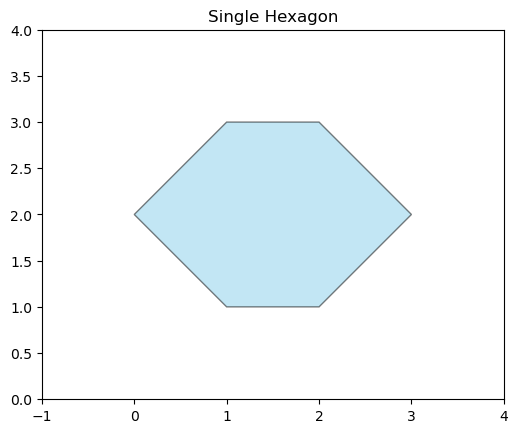

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

# Example: 2D hexagon vertices
hexagon_vertices = np.array([
    [1, 1],
    [2, 1],
    [3, 2],
    [2, 3],
    [1, 3],
    [0, 2]
])

# Create the figure
fig, ax = plt.subplots()

# Add polygon patch
hexagon = Polygon(hexagon_vertices, closed=True, facecolor='skyblue', edgecolor='black', alpha=0.5)
ax.add_patch(hexagon)

# Set limits so you can see it
ax.set_xlim(-1, 4)
ax.set_ylim(0, 4)
ax.set_aspect('equal')  # Keep aspect ratio square

plt.title("Single Hexagon")
plt.show()

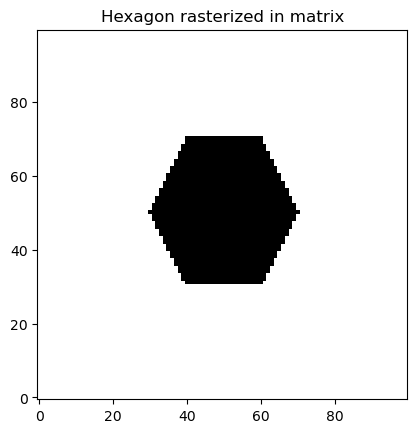

In [12]:
import numpy as np
from matplotlib.path import Path

# Size of the grid
grid_size = 100
matrix = np.zeros((grid_size, grid_size), dtype=int)

# Hexagon vertices (in grid coordinates)
hexagon_vertices = np.array([
    [40, 30],
    [60, 30],
    [70, 50],
    [60, 70],
    [40, 70],
    [30, 50]
])

# Make a Path object
hex_path = Path(hexagon_vertices)

# Generate all points in the grid
xv, yv = np.meshgrid(np.arange(grid_size), np.arange(grid_size))
points = np.vstack((xv.flatten(), yv.flatten())).T

# Check which points are inside the hexagon
mask = hex_path.contains_points(points).reshape(grid_size, grid_size)

# Fill the matrix
matrix[mask] += 1

plt.imshow(matrix, origin='lower', cmap='Greys')
plt.title("Hexagon rasterized in matrix")
plt.show()

## Graphs

### 3D Map

In [ ]:
# Create X, Y coordinates
x = np.arange(matrix.shape[1])
y = np.arange(matrix.shape[0])
X, Y = np.meshgrid(x, y)

# Plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, matrix, cmap='terrain')  # 'terrain' colormap looks like mountains
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Frequency")
plt.show()

### Heat map

In [ ]:
plt.imshow(matrix, cmap='hot', interpolation='nearest')
plt.colorbar(label='Value')  # adds a color scale
plt.title("Heatmap of Matrix")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()